# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Nicholas Frank

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [3]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nicholasfrank2x
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:05<00:00, 68.6MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [14]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

,class,image_count,percent
0,fire_images,755,75.575576
1,non_fire_images,244,24.424424


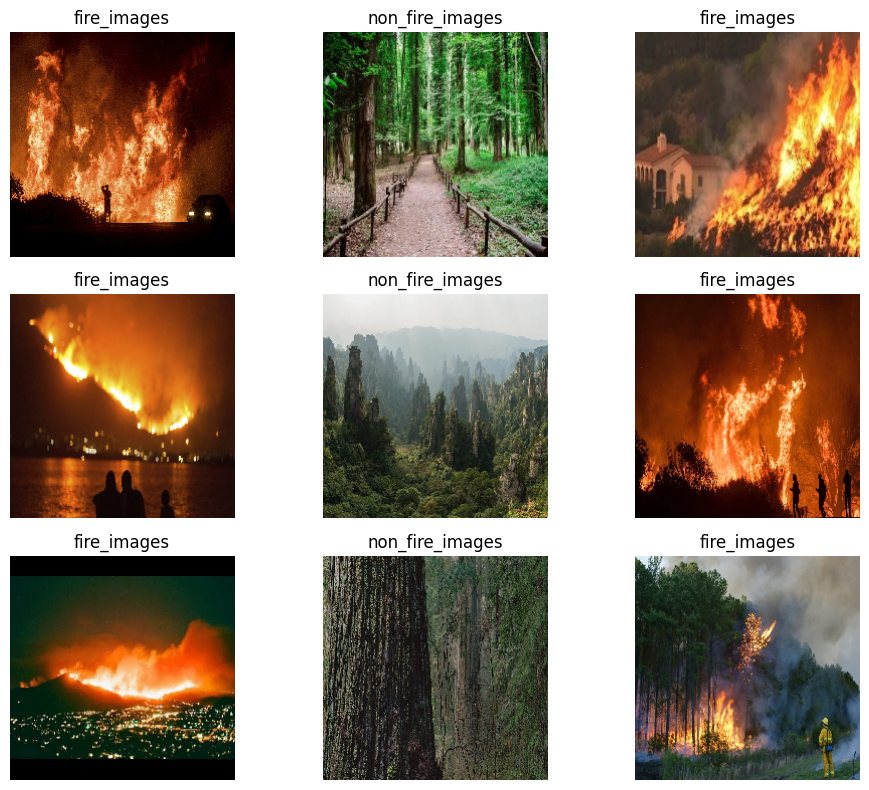

In [5]:
# Your exploration here
# Count files in each class folder
fire_class_counts = {}
for class_name in class_names_fire:
    class_dir = os.path.join(data_dir_fire, class_name)
    count = sum(
        1 for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f))
    )
    fire_class_counts[class_name] = count

fire_counts_df = pd.DataFrame({
    "class": list(fire_class_counts.keys()),
    "image_count": list(fire_class_counts.values())
})
fire_counts_df["percent"] = 100 * fire_counts_df["image_count"] / fire_counts_df["image_count"].sum()
display(fire_counts_df)

# Look at a few examples from the training set
plt.figure(figsize=(10, 8))
for images, labels in train_raw_fire.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()



*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The Fire dataset contains 755 fire images and 244 non-fire images, so about 75.6% of the dataset is fire and 24.4% is non-fire. This means the dataset is fairly imbalanced, with roughly three times as many fire images as non-fire images. Because of this imbalance, accuracy alone may make the model look better than it really is, so I should also look at the confusion matrix and how often each class is misclassified. This is especially important because missing a real fire is more serious than incorrectly identifying a non-fire image as fire. I used the provided seeded split so that the training, validation, and test sets remain reproducible.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [17]:
# Preprocess the data here
# MobileNetV2 expects images preprocessed to its input scale.
# The raw directory loader gives fire_images label 0 and non_fire_images label 1.
# For this binary task, remap labels so FIRE = 1 and NON-FIRE = 0. This makes
# the sigmoid output directly interpretable as P(fire), which is useful when
# discussing false negatives and changing the decision threshold.

def preprocess_fire(images, labels):
    images = preprocess_input(tf.cast(images, tf.float32))
    labels = 1 - tf.cast(labels, tf.int32)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_fire = train_raw_fire.map(preprocess_fire, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_fire = val_raw_fire.map(preprocess_fire, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_fire = test_raw_fire.map(preprocess_fire, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

fire_display_names = ["non_fire", "fire"]



In [7]:
# Build your model here
base_fire = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_fire.trainable = False

inputs_fire = tf.keras.Input(shape=(224, 224, 3))
x = base_fire(inputs_fire, training=False)
x = GlobalAveragePooling2D()(x)
outputs_fire = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs_fire, outputs_fire)
model_fire.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile your model here
model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



## 1D — Train and Evaluate

In [9]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)



Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.7343 - loss: 0.5192 - val_accuracy: 0.7986 - val_loss: 0.4113
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9314 - loss: 0.2098 - val_accuracy: 0.9496 - val_loss: 0.1752
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9629 - loss: 0.1363 - val_accuracy: 0.9496 - val_loss: 0.1548
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9714 - loss: 0.1086 - val_accuracy: 0.9496 - val_loss: 0.1072
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9829 - loss: 0.0914 - val_accuracy: 0.9640 - val_loss: 0.0893


In [10]:
# Report validation and test accuracy here
val_loss_fire, val_acc_fire = model_fire.evaluate(val_fire, verbose=0)
test_loss_fire, test_acc_fire = model_fire.evaluate(test_fire, verbose=0)

print(f"Fire validation accuracy: {val_acc_fire:.4f} ({val_acc_fire*100:.2f}%)")
print(f"Fire test accuracy:       {test_acc_fire:.4f} ({test_acc_fire*100:.2f}%)")



Fire validation accuracy: 0.9568 (95.68%)
Fire test accuracy:       0.9750 (97.50%)


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

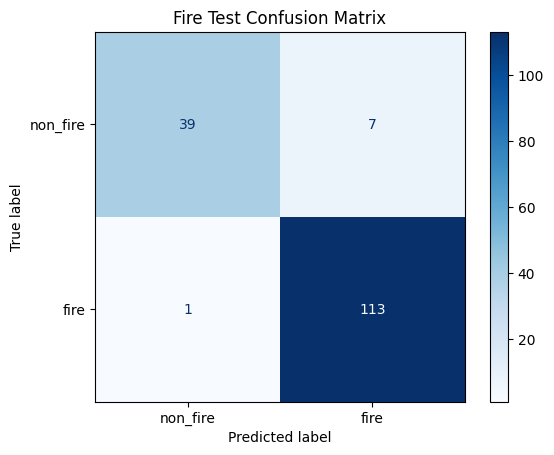

False alarms: 7
Missed fires: 1


In [18]:
fire_y_true = []
fire_y_prob = []

for images, labels in test_fire:
    probs = model_fire.predict(images, verbose=0).ravel()

    fire_y_true.extend(labels.numpy())
    fire_y_prob.extend(probs)

fire_y_true = np.array(fire_y_true)
fire_y_prob = np.array(fire_y_prob)

fire_y_pred = (fire_y_prob >= 0.5).astype(int)

cm_fire = confusion_matrix(
    fire_y_true,
    fire_y_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_fire,
    display_labels=["non_fire", "fire"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Fire Test Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm_fire.ravel()

print("False alarms:", fp)
print("Missed fires:", fn)


*Your answer:*
A false negative is more costly in this situation because it means the model failed to detect a real fire. Missing a real fire could delay a warning and potentially put people or property at risk, while a false positive would mainly cause an unnecessary alarm. Because of this, in a real fire detection system I would likely use a threshold lower than 0.5. Lowering the threshold would make the model more likely to classify an image as fire, which should reduce missed fires and increase fire recall, although it would also cause more false alarms.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [12]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [15]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [22]:
# 2B — Build a Frozen Transfer Learning Model

# Preprocess images for MobileNetV2
def preprocess_sat(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels


# Preprocess, cache, and prefetch each dataset
train_sat = (
    train_raw_sat
    .map(preprocess_sat, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_sat = (
    val_raw_sat
    .map(preprocess_sat, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_sat = (
    test_raw_sat
    .map(preprocess_sat, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)




In [23]:
# Build your model here
# EuroSAT is a multiclass classification problem
num_sat_classes = len(class_names_sat)

print("EuroSAT classes:", class_names_sat)
print("Number of EuroSAT classes:", num_sat_classes)


# Load MobileNetV2 without its original ImageNet classifier
base_sat = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained MobileNetV2 layers
base_sat.trainable = False


# Build our classifier on top of MobileNetV2
inputs_sat = tf.keras.Input(shape=(224, 224, 3))

# training=False keeps MobileNetV2's BatchNormalization layers
# in inference mode while the base model is frozen
x = base_sat(inputs_sat, training=False)

# Convert the feature maps into one feature vector per image
x = GlobalAveragePooling2D()(x)

# 10-class output layer for EuroSAT
outputs_sat = Dense(
    num_sat_classes,
    activation="softmax"
)(x)

model_sat = Model(
    inputs=inputs_sat,
    outputs=outputs_sat
)



EuroSAT classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of EuroSAT classes: 10


In [24]:
# Compile the model
# Sparse categorical crossentropy is appropriate because
# the labels are integer class IDs rather than one-hot encoded vectors
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model_sat.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [25]:
# 2C — Train and Evaluate the EuroSAT Model

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=2
)

# Report validation and test accuracy here
val_loss_sat, val_acc_sat = model_sat.evaluate(
    val_sat,
    verbose=0
)

test_loss_sat, test_acc_sat = model_sat.evaluate(
    test_sat,
    verbose=0
)

print(f"EuroSAT validation accuracy: {val_acc_sat:.4f} ({val_acc_sat * 100:.2f}%)")
print(f"EuroSAT test accuracy:       {test_acc_sat:.4f} ({test_acc_sat * 100:.2f}%)")


Epoch 1/2
591/591 ━━━━━━━━━━━━━━━━━━━━ 1016s 2s/step - accuracy: 0.8776 - loss: 0.3780 - val_accuracy: 0.9279 - val_loss: 0.2315
Epoch 2/2
591/591 ━━━━━━━━━━━━━━━━━━━━ 978s 2s/step - accuracy: 0.9357 - loss: 0.1940 - val_accuracy: 0.9373 - val_loss: 0.1957
EuroSAT validation accuracy: 0.9376 (93.76%)
EuroSAT test accuracy:       0.9328 (93.28%)


In [26]:
# Report validation and test accuracy here
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat, verbose=0)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=0)

print(f"EuroSAT validation accuracy: {val_acc_sat:.4f} ({val_acc_sat*100:.2f}%)")
print(f"EuroSAT test accuracy:       {test_acc_sat:.4f} ({test_acc_sat*100:.2f}%)")



KeyboardInterrupt: 

## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

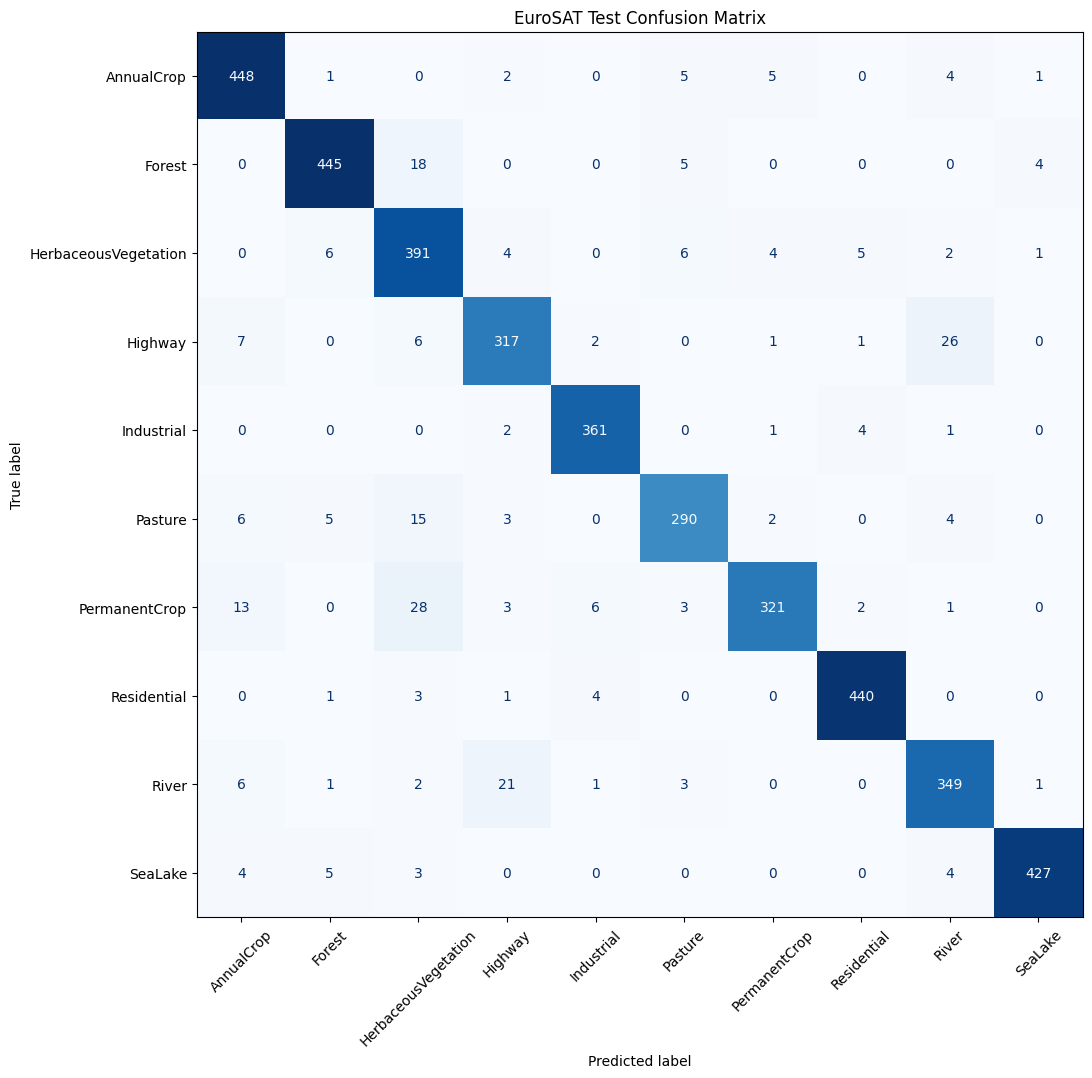

Most common confusion: PermanentCrop -> HerbaceousVegetation (28 images)


In [28]:
# 2D — EuroSAT Confusion Matrix

sat_y_true = []
sat_y_pred = []

for images, labels in test_sat:
    probs = model_sat.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    sat_y_true.extend(labels.numpy())
    sat_y_pred.extend(preds)

sat_y_true = np.array(sat_y_true)
sat_y_pred = np.array(sat_y_pred)

# Build confusion matrix
cm_sat = confusion_matrix(
    sat_y_true,
    sat_y_pred,
    labels=np.arange(num_sat_classes)
)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(11, 11))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sat,
    display_labels=class_names_sat
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("EuroSAT Test Confusion Matrix")
plt.tight_layout()
plt.show()


# Find most common incorrect prediction
cm_sat_offdiag = cm_sat.copy()
np.fill_diagonal(cm_sat_offdiag, 0)

true_idx, pred_idx = np.unravel_index(
    np.argmax(cm_sat_offdiag),
    cm_sat_offdiag.shape
)

most_confused_count = cm_sat_offdiag[true_idx, pred_idx]

print(
    f"Most common confusion: "
    f"{class_names_sat[true_idx]} -> "
    f"{class_names_sat[pred_idx]} "
    f"({most_confused_count} images)"
)


*Your answer:*
The most common confusion was PermanentCrop being predicted as HerbacousVegeation, which occurred 28 times. This makes visual sense because EuroSAT images are taken from above, and different land-use classes can have similar colors, textures, vegetation, roads, and building patterns. These similarities can make some classes difficult to distinguish even when overall accuracy is high.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | .9568|.9376 |
| Test Accuracy |.9750 |.9726 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. I think the Fire/Smoke dataset is a closer match to ImageNet than EuroSAT. ImageNet mainly contains ordinary RGB photographs of objects and scenes, so fire images are more similar to the type of images MobileNetV2 originally learned from. EuroSAT contains satellite imagery viewed from above, where classification depends more heavily on textures, patterns, vegetation, and spatial layouts. My results support this because the Fire/Smoke model achieved 97.50% test accuracy, while the EuroSAT model achieved 93.28% test accuracy. Both performed well, but the model transferred slightly better to the dataset that was more similar to its original training data.
2. I think both models could potentially improve by unfreezing some of the later MobileNetV2 layers and fine-tuning them with a small learning rate. I would expect fine-tuning to help EuroSAT more, because satellite imagery is a larger domain shift from ImageNet. Fine-tuning could allow the later layers to learn features that are more specific to overhead land-use patterns. The Fire model might also improve, but its 97.50% test accuracy shows that the frozen ImageNet features already transfer very well to that task.




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
The Fire dataset was imbalanced, with about 75.6% fire images and 24.4% non-fire images, so I considered the confusion matrix in addition to accuracy because missing an actual fire is more important than producing a false alarm. For the Fire model, I used one output neuron with sigmoid activation and binary cross-entropy loss because it is a binary classification problem. For EuroSAT, I used 10 output neurons with softmax activation and sparse categorical cross-entropy loss because the model must choose between 10 mutually exclusive land-use classes. The Fire model achieved 97.50% test accuracy, while the EuroSAT model achieved 93.28% test accuracy. These results suggest that the usefulness of a pretrained model depends not only on how capable the model is, but also on how closely its original training data matches the new task, since ordinary fire photographs are more similar to ImageNet images than satellite imagery.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.